In [1]:
import matplotlib
import seaborn
import plotly

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
sales_data = pd.read_csv('ecom_cosmetics_sales_data.csv', index_col=0)
sales_data.head()

,visitors,sales,conversion,avg_order_value,income
2024-01-01,2167,75,0.032994,89.753640,6731.523007
2024-01-02,1983,52,0.036120,91.450902,4755.446886
2024-01-03,2226,86,0.035063,70.794979,6088.368237
2024-01-04,2495,54,0.035488,100.061359,5403.313391
2024-01-05,1976,82,0.031135,94.492687,7748.400304


In [4]:
type(sales_data.index[0])

str

In [5]:
# для перетворення індексу об'єкта DataFrame (або Series) у формат дати та часу (DatetimeIndex) 
sales_data.index = pd.to_datetime(sales_data.index)

In [6]:
type(sales_data.index[0])

pandas._libs.tslibs.timestamps.Timestamp

## Гістограма (Histogram)

In [7]:
sales_data

,visitors,sales,conversion,avg_order_value,income
2024-01-01,2167,75,0.032994,89.753640,6731.523007
2024-01-02,1983,52,0.036120,91.450902,4755.446886
2024-01-03,2226,86,0.035063,70.794979,6088.368237
2024-01-04,2495,54,0.035488,100.061359,5403.313391
2024-01-05,1976,82,0.031135,94.492687,7748.400304
...,...,...,...,...,...
2024-12-26,3241,109,0.034080,72.565835,7909.676037
2024-12-27,3550,123,0.035092,97.766750,12025.310241
2024-12-28,2563,83,0.026738,94.113609,7811.429547
2024-12-29,2722,61,0.022301,103.277044,6299.899700


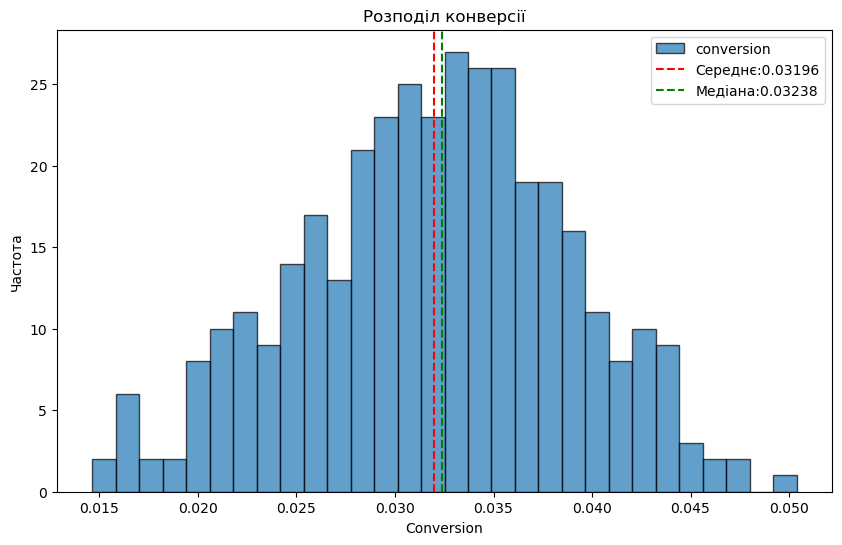

In [8]:
# Розподіл конверсії
sales_data['conversion'].plot.hist(    # будує гістограму розподілу конверсії
    bins=30,             # розбиває дані на 30 інтервалів
    figsize=(10, 6),
    alpha=0.7,           # ступінь прозорості стовпців
    edgecolor='black',   # кожен стовпець матиме чорні межі
    title='Розподіл конверсії', 
    xlabel='Conversion',
    ylabel='Частота',
)
plt.axvline(
    sales_data['conversion'].mean(),  # обчислюємо середнє значення конверсії → де провести лінію по осі X
    color='red',                      # колір лінії (червоний)
    linestyle='--',                   # тип лінії (пунктир)
    label=f"Середнє:{sales_data['conversion'].mean():.5f}"    # підпис для легенди з форматуванням до 5 знаків
)
plt.axvline(
    sales_data['conversion'].median(),  # обчислюємо медіану → де провести вертикальну лінію
    color='green',
    linestyle='--',
    label=f"Медіана:{sales_data['conversion'].median():.5f}"
)
plt.legend()   # показує легенду
plt.show()

## Коробковий графік (Box Plot)

In [9]:
# Розподіл продажів за днями тижня
sales_data['weekday'] = sales_data.index.day_name()

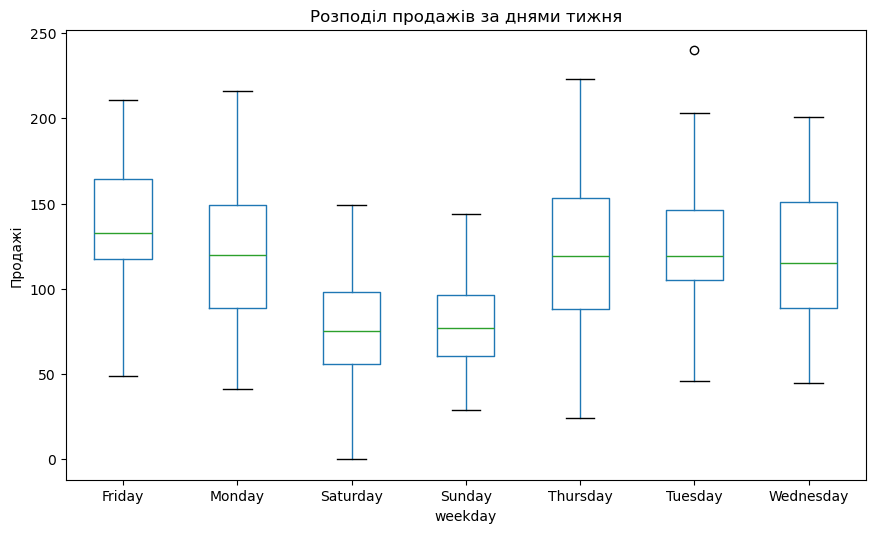

In [10]:
# Спосіб 1: через boxplot() - зручніше для групування
sales_data.boxplot(
    column='sales',
    by='weekday',
    figsize=(10, 6),
    grid = False
)
plt.title('Розподіл продажів за днями тижня')
plt.suptitle('')      # Видаляємо автоматичний заголовок
plt.ylabel('Продажі')
plt.show()
    

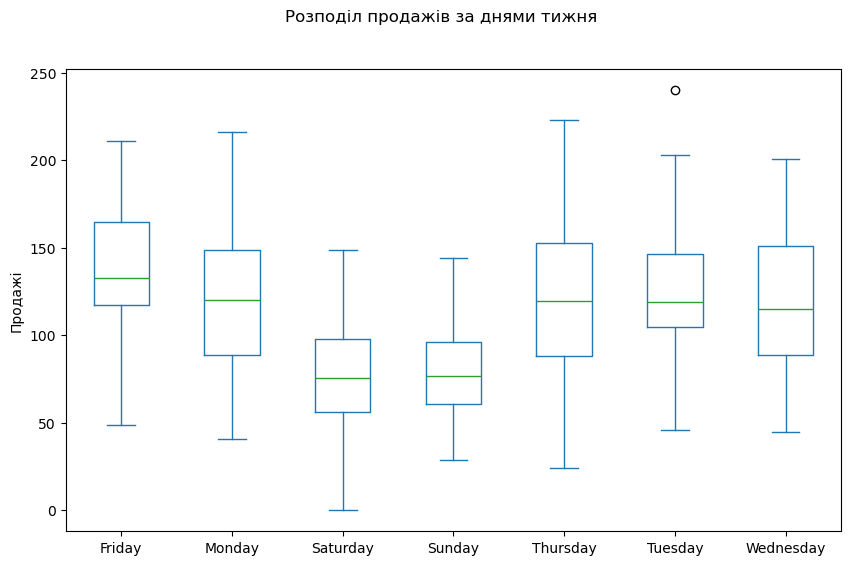

In [11]:
# Спосіб 2: через plot.box()
sales_data[['sales','weekday']].plot.box(
    by='weekday',
    figsize=(10, 6),
    title='Розподіл продажів за днями тижня',
    ylabel='Продажі'
)
plt.title('');    

In [12]:
# 1. Встановлюємо правильний порядок днів
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Задаємо категорійну змінну з порядком для weekday
sales_data['weekday']=pd.Categorical(sales_data['weekday'],categories=ordered_days, ordered=True)

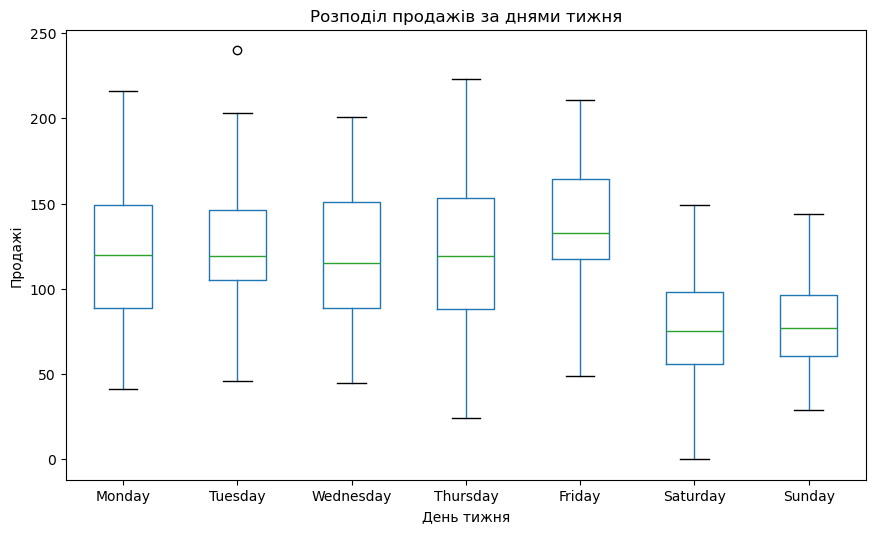

In [13]:
# 3. Побудова boxplot з англійськими днями
sales_data.boxplot(
    column='sales',
    by='weekday',
    figsize=(10, 6),
    grid=False   # не малювати сітку
)
plt.title('Розподіл продажів за днями тижня')
plt.ylabel('Продажі')
plt.xlabel('День тижня')
plt.suptitle('')    # Прибирає автоматичний заголовок
plt.show()

## Діаграма розсіювання

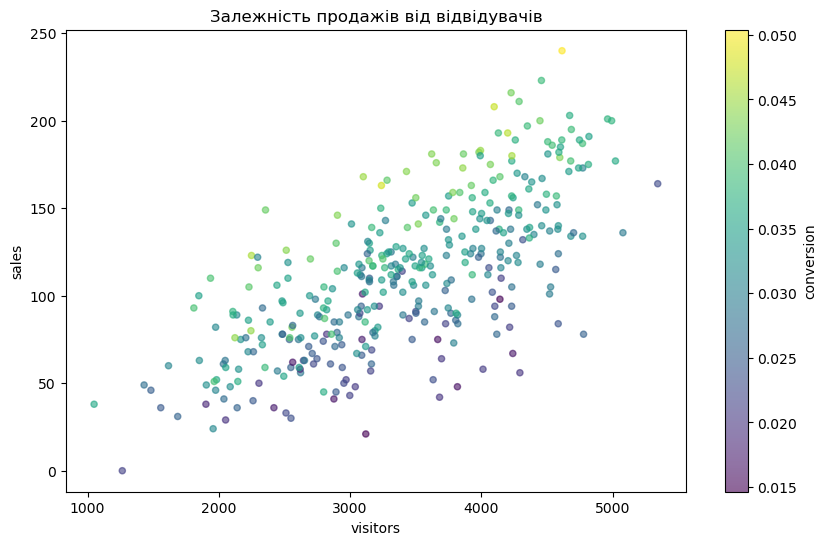

In [14]:
# Залежність продажів від відвідувачів
sales_data.plot.scatter(
    x='visitors',
    y='sales',
    c='conversion',
    colormap='viridis',
    title='Залежність продажів від відвідувачів',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()

## Кругова діаграма

In [15]:
# Частка продажів за кварталами
quarterly_sales = sales_data['sales'].resample('QE').sum()
quarterly_sales
# Групуємо дані за кварталами (QE = кінець кварталу) 
# та обчислюємо загальну суму продажів у кожному кварталі

2024-03-31     7297
2024-06-30    11994
2024-09-30    12201
2024-12-31     9262
Freq: QE-DEC, Name: sales, dtype: int64

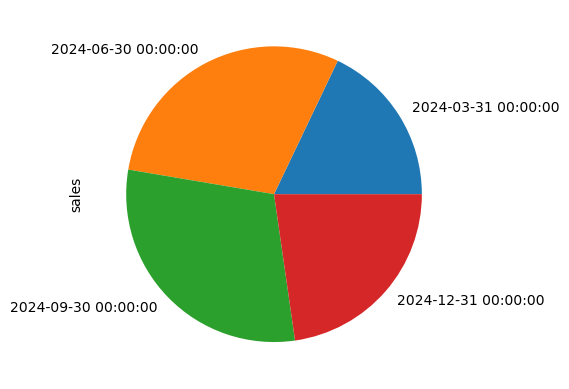

In [16]:
quarterly_sales.plot.pie(
    # # figsize=(8, 8),
    # autopct='%1.1f%%',
    # labels=['Q1', 'Q2', 'Q3', 'Q4'],
    # title='Частка продажів за кварталами',
    # ylabel='',
);

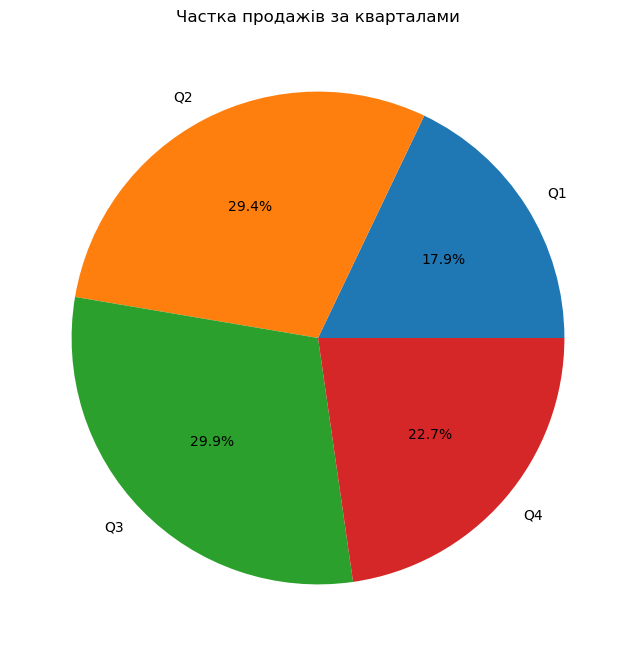

In [17]:
quarterly_sales.plot.pie(
    figsize=(8,8),
    autopct='%1.1f%%',        # формат відображення відсотків на секторі діаграми
    labels=['Q1','Q2','Q3','Q4'],
    title='Частка продажів за кварталами',
    ylabel='',   # порожній підпис осі Y
);

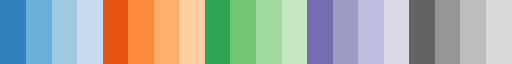

In [18]:
plt.cm.tab20c

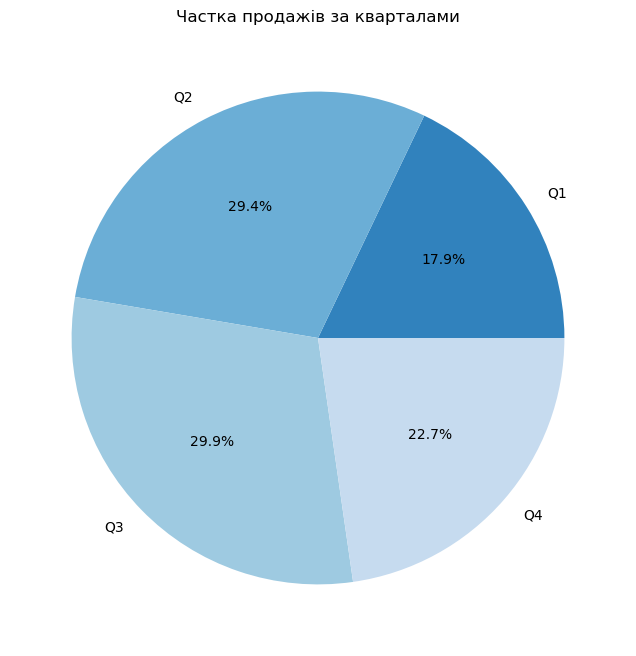

In [19]:
quarterly_sales.plot.pie(
    figsize=(8,8),
    autopct='%1.1f%%',        # формат відображення відсотків на секторі діаграми
    labels=['Q1','Q2','Q3','Q4'],
    title='Частка продажів за кварталами',
    ylabel='',   # порожній підпис осі Y
    colors= plt.cm.tab20c.colors       # кольорова палітра
);

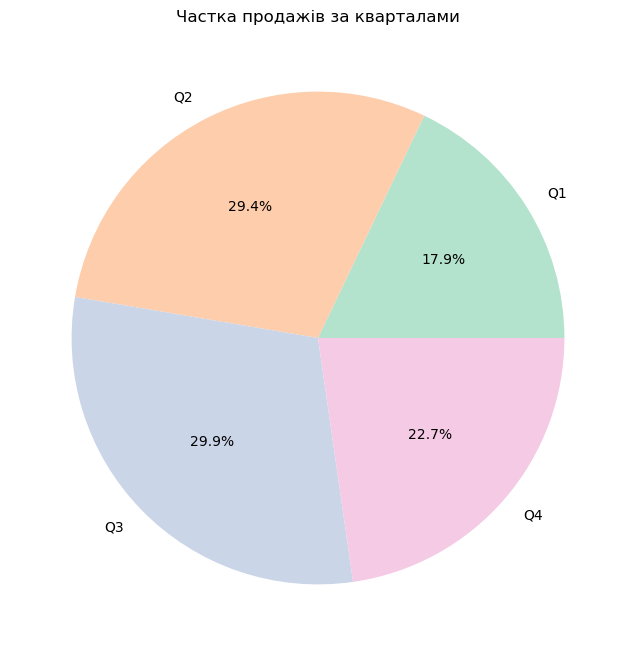

In [20]:
quarterly_sales.plot.pie(
    figsize=(8,8),
    autopct='%1.1f%%',        # формат відображення відсотків на секторі діаграми
    labels=['Q1','Q2','Q3','Q4'],
    title='Частка продажів за кварталами',
    ylabel='',   # порожній підпис осі Y
    colors= plt.cm.Pastel2.colors       # пастельна кольорова палітра
);

## Area Plot

In [21]:
# Створимо дані про канали продажів
channels = pd.DataFrame({
    'Онлайн': sales_data['sales'] * 0.6,
    'Офлайн': sales_data['sales'] * 0.3,
    'Партнери': sales_data['sales'] * 0.1
}, index=sales_data.index)

In [22]:
import numpy as np

In [27]:
channels[:5]  # повертає перші 5 рядків таблиці channels

,Онлайн,Офлайн,Партнери
2024-01-01,45.0,22.5,7.5
2024-01-02,31.2,15.6,5.2
2024-01-03,51.6,25.8,8.6
2024-01-04,32.4,16.2,5.4
2024-01-05,49.2,24.6,8.2


In [26]:
np.allclose(channels.sum(axis=1), sales_data['sales'])   # перевіряє чи сума по каналах дорівнює загальним продажам

True

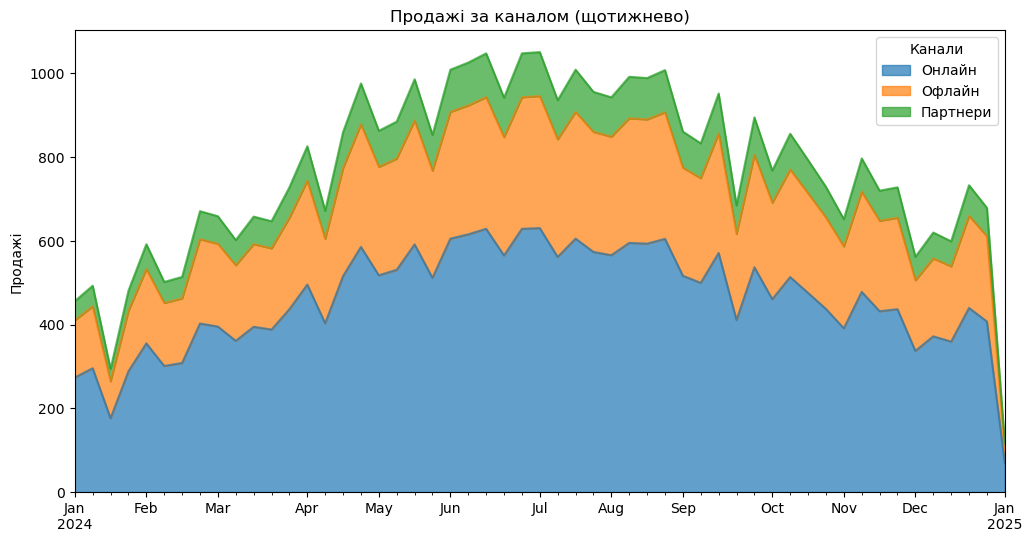

In [30]:
channels.resample('W').sum().plot.area(     # групує дані по тижнях ('W'), сумує значення і будує area-графік (площинний)
    figsize=(12, 6),
    alpha=0.7
)
plt.title('Продажі за каналом (щотижнево)')
plt.ylabel('Продажі')
plt.legend(title='Канали')     # додає легенду з назвою "Канали"
plt.show()
